In [1]:
#!/usr/bin/env python3
from opendbc.car.chery.values import CAR
from opendbc.car.vehicle_model import VehicleModel
from opendbc.car.chery.carcontroller import get_max_angle_delta, get_max_angle
from opendbc.car.chery.interface import CarInterface

def get_vm(car_name):
  return VehicleModel(CarInterface.get_non_essential_params(car_name))


<module 'car.capnp' from '/Users/daffigusti/development/openpilot/opendbc_sunnypilot/opendbc/car/car.capnp'>


kj/filesystem-disk-unix.c++:1734: warning: PWD environment variable doesn't match current directory; pwd = /


In [2]:
# Only platforms not in dashcam mode!
#PLATFORMS = {str(platform): platform for platform in CAR if
#             platform.config.flags & HyundaiFlags.CANFD_ANGLE_STEERING and not CarInterface.get_non_essential_params(str(platform)).dashcamOnly}


PLATFORMS = {str(platform): platform for platform in CAR }

STEER_ANGLE_MAX = 180.
BASELINE_CAR = "GENESIS_GV80_2025"

In [3]:
from opendbc.car import get_safety_config, structs

print(structs.CarParams.SafetyModel.cheryCanFd)
PLATFORMS

35


{'CHERY_OMODA_E5': <CAR.CHERY_OMODA_E5>}

In [4]:
import numpy as np
import matplotlib.pyplot as plt

SPEEDS = np.linspace(1, 40, 200)

def compare_max_angle_plot(car_name, baseline_car, only_relevant_angles=True):
    """
    Plot max steering angles vs speed for car_name and baseline,
    then print a numeric comparison table at a lower resolution.
    """
    baseline_vm = get_vm(baseline_car)
    current_vm = get_vm(car_name)

    speeds = []
    baseline_angles = []
    current_angles = []

    for speed in SPEEDS:  # finer resolution for smooth plots
        current_max = get_max_angle(speed, current_vm)
        baseline_max = get_max_angle(speed, baseline_vm)
        if only_relevant_angles and (current_max > STEER_ANGLE_MAX and baseline_max > STEER_ANGLE_MAX):
            continue

        speeds.append(speed)
        baseline_angles.append(baseline_max)
        current_angles.append(current_max)

    plt.figure(figsize=(10, 5))
    plt.plot(speeds, current_angles, label=f"{car_name}", color="blue", linewidth=2)
    plt.plot(speeds, baseline_angles, label=f"{baseline_car} (baseline)", color="gray", linestyle="--", linewidth=2)
    plt.title("Max Steering Angle vs Speed")
    plt.xlabel("Speed (m/s)")
    plt.ylabel("Max Angle (degrees)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print table on fewer points for clarity
    print(f"\n[Max Angle Comparison] {car_name} vs {baseline_car}")
    print(f"{'Speed (m/s)':<12}{'Max Angle':<12}{'Baseline':<12}{'Diff (%)':<12}")
    for speed in np.linspace(1, 40, 10):
        baseline_max_angle = get_max_angle(speed, baseline_vm)
        current_max_angle = get_max_angle(speed, current_vm)

        if only_relevant_angles and current_max_angle > STEER_ANGLE_MAX:
            continue

        angle_diff_pct = ((current_max_angle - baseline_max_angle) / baseline_max_angle) * 100 if baseline_max_angle != 0 else 0
        print(f"{speed:<12.1f}{current_max_angle:<12.2f}{baseline_max_angle:<12.2f}{angle_diff_pct:<12.2f}")

def compare_max_angle_delta_plot(car_name, baseline_car="HYUNDAI_IONIQ_5_PE"):
    """
    Plot max steering angle delta vs speed for car_name and baseline,
    then print numeric comparison table at lower resolution.
    """
    baseline_vm = get_vm(baseline_car)
    current_vm = get_vm(car_name)

    speeds = []
    baseline_deltas = []
    current_deltas = []

    for speed in SPEEDS:
        speeds.append(speed)
        baseline_deltas.append(get_max_angle_delta(speed, baseline_vm))
        current_deltas.append(get_max_angle_delta(speed, current_vm))

    plt.figure(figsize=(10, 5))
    plt.plot(speeds, current_deltas, label=f"{car_name}", color="green", linewidth=2)
    plt.plot(speeds, baseline_deltas, label=f"{baseline_car} (baseline)", color="gray", linestyle="--", linewidth=2)
    plt.title("Max Steering Angle Delta vs Speed")
    plt.xlabel("Speed (m/s)")
    plt.ylabel("Max Delta (deg/frame)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print numeric table
    print(f"\n[Max Angle Delta Comparison] {car_name} vs {baseline_car}")
    print(f"{'Speed (m/s)':<12}{'Max Delta':<12}{'Baseline':<12}{'Diff (%)':<12}")
    for speed in np.linspace(1, 40, 10):
        baseline_max_delta = get_max_angle_delta(speed, baseline_vm)
        current_max_delta = get_max_angle_delta(speed, current_vm)

        delta_diff_pct = ((current_max_delta - baseline_max_delta) / baseline_max_delta) * 100 if baseline_max_delta != 0 else 0
        print(f"{speed:<12.1f}{current_max_delta:<12.4f}{baseline_max_delta:<12.4f}{delta_diff_pct:<12.2f}")


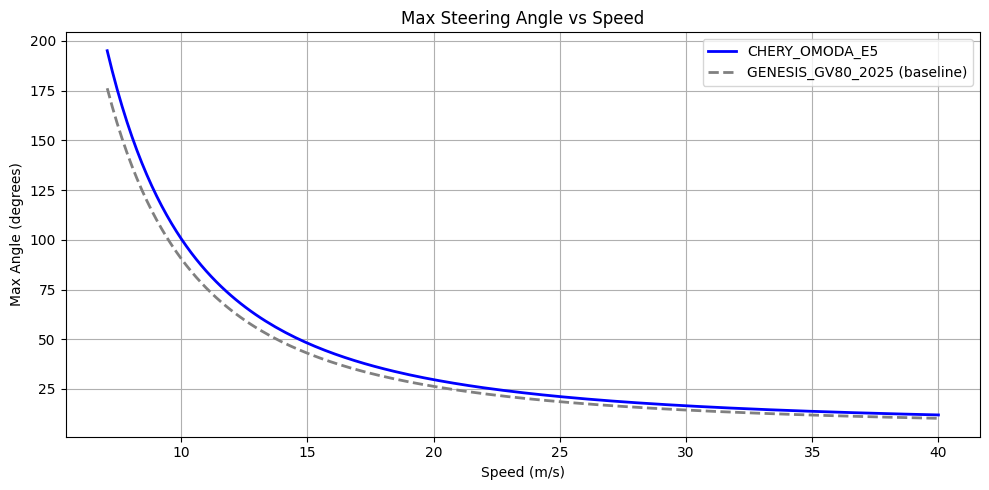


[Max Angle Comparison] CHERY_OMODA_E5 vs GENESIS_GV80_2025
Speed (m/s) Max Angle   Baseline    Diff (%)    
9.7         107.31      96.66       11.01       
14.0        54.32       48.64       11.68       
18.3        34.19       30.39       12.49       
22.7        24.45       21.57       13.37       
27.0        19.02       16.64       14.27       
31.3        15.67       13.61       15.15       
35.7        13.47       11.62       15.97       
40.0        11.95       10.24       16.73       
------------------------------------------------------------------------------------------------------------------------
Comparison complete across 1 Hyundai models with CANFD angle steering support.


In [5]:
for car_name in PLATFORMS:
    compare_max_angle_plot(car_name, BASELINE_CAR, True)
    print("-"*120)
print(f"Comparison complete across {len(PLATFORMS)} Hyundai models with CANFD angle steering support.")

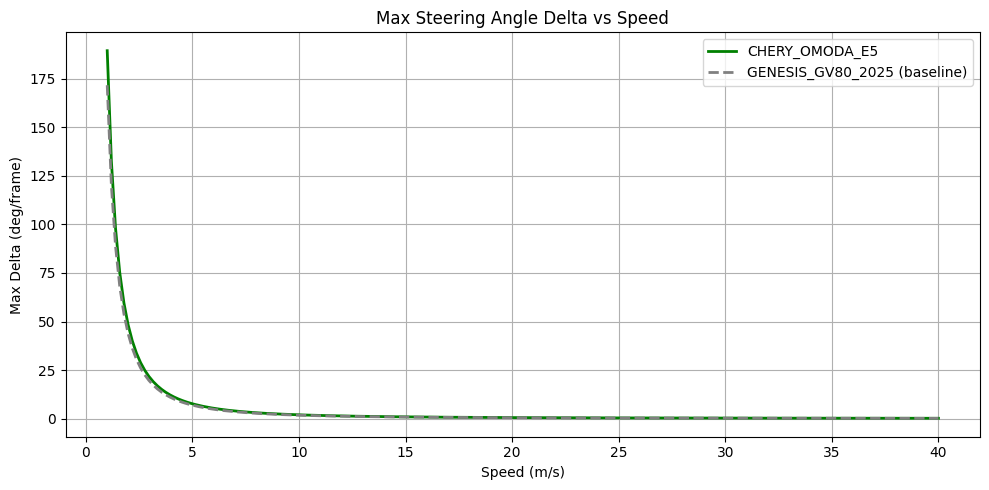


[Max Angle Delta Comparison] CHERY_OMODA_E5 vs GENESIS_GV80_2025
Speed (m/s) Max Delta   Baseline    Diff (%)    
1.0         189.3862    171.6311    10.34       
5.3         6.7746      6.1280      10.55       
9.7         2.1461      1.9332      11.01       
14.0        1.0863      0.9727      11.68       
18.3        0.6838      0.6079      12.49       
22.7        0.4891      0.4314      13.37       
27.0        0.3803      0.3328      14.27       
31.3        0.3135      0.2722      15.15       
35.7        0.2695      0.2324      15.97       
40.0        0.2390      0.2047      16.73       
Comparison complete across 1 Hyundai models with CANFD angle steering support.


In [6]:
for car_name in PLATFORMS:
    compare_max_angle_delta_plot(car_name, BASELINE_CAR)
print(f"Comparison complete across {len(PLATFORMS)} Hyundai models with CANFD angle steering support.")